# DLAttack Replication with TorchRec Two-Tower Model + DMP on MovieLens-1M

**Reference:** Huang et al., *Data Poisoning Attacks to Deep Learning Based Recommender Systems* (NDSS 2021) — [arXiv:2101.02644](https://arxiv.org/abs/2101.02644)

This notebook replicates the DLAttack data poisoning attack using a **TorchRec Two-Tower** recommender model with **DistributedModelParallel (DMP)** on the MovieLens-1M dataset. DMP triggers fbgemm's fused Table Batched Embedding (TBE) kernels even on single GPU.

1. **Baseline training** — DMP-wrapped Two-Tower with fused TBE kernels
2. **DLAttack** — surrogate optimization + fake user injection
3. **Evaluation** — target item promotion + overall metrics
4. **Detection** — TIA statistical baseline

**Requirements:** GPU runtime (Runtime > Change runtime type > A100 GPU)

---

## Phase 0: Setup

In [1]:
# Clone the repo (skip if already cloned)
import os
if not os.path.exists("embdguard"):
    !git clone https://github.com/aliafzal/embdguard.git
%cd /content/embdguard/dlattack_research

Cloning into 'embdguard'...
remote: Enumerating objects: 76, done.
remote: Counting objects: 100% (76/76), done.
remote: Compressing objects: 100% (55/55), done.
remote: Total 76 (delta 38), reused 58 (delta 20), pack-reused 0 (from 0)
Receiving objects: 100% (76/76), 45.14 KiB | 2.38 MiB/s, done.
Resolving deltas: 100% (38/38), done.
/content/embdguard/dlattack_research


In [2]:
# Install TorchRec + fbgemm-gpu
!pip install -q torchrec fbgemm-gpu

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 4.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 833.1/833.1 kB 18.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.6/731.6 kB 56.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 551.7/551.7 MB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 465.5/465.5 kB 47.3 MB/s eta 0:00:00


In [3]:
# Verify environment and initialize distributed process group
import torch
import torchrec
import numpy as np
import pandas as pd

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"torch:    {torch.__version__}")
print(f"torchrec: {torchrec.__version__}")
print(f"device:   {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU:      {torch.cuda.get_device_name(0)}")

# Initialize distributed process group (required for DMP even on single GPU)
from src.distributed import init_process_group
init_process_group(DEVICE)
print("Distributed process group initialized.")

torch:    2.10.0+cu128
torchrec: 1.4.0
device:   cuda
GPU:      NVIDIA A100-SXM4-40GB
Distributed process group initialized.


In [4]:
import os
os.makedirs("checkpoints", exist_ok=True)
os.makedirs("results", exist_ok=True)

## Phase 1: Download & Load MovieLens-1M

In [5]:
from src.dataset import download_ml1m, load_ratings, split_data

download_ml1m()
df, n_users, n_items, user_map, item_map = load_ratings()
train_df, test_df = split_data(df)

print(f"\nUsers: {n_users:,}  |  Items: {n_items:,}")
print(f"Train: {len(train_df):,} interactions  |  Test: {len(test_df):,} interactions")

Download complete.
Extracted.
Users: 6040, Items: 3706, Interactions: 1000209

Users: 6,040  |  Items: 3,706
Train: 994,169 interactions  |  Test: 6,040 interactions


In [6]:
# Quick data summary
interactions_per_user = train_df.groupby("user_id").size()
interactions_per_item = train_df.groupby("item_id").size()

print(f"Interactions per user — mean: {interactions_per_user.mean():.1f}, "
      f"median: {interactions_per_user.median():.0f}, "
      f"min: {interactions_per_user.min()}, max: {interactions_per_user.max()}")
print(f"Interactions per item — mean: {interactions_per_item.mean():.1f}, "
      f"median: {interactions_per_item.median():.0f}, "
      f"min: {interactions_per_item.min()}, max: {interactions_per_item.max()}")

Interactions per user — mean: 164.6, median: 95, min: 19, max: 2313
Interactions per item — mean: 268.4, median: 122, min: 1, max: 3410


## Phase 2: Model Sanity Check

Test the TwoTower model with KJT-based forward pass and DMP wrapping.

In [7]:
from src.model import build_ebc, TwoTower, TwoTowerTrainTask, make_kjt

# Quick forward pass test with plain TwoTower
test_ebc = build_ebc(n_users=100, n_items=200, embedding_dim=32, device=torch.device("cpu"))
test_model = TwoTower(test_ebc, layer_sizes=[64, 32], device=torch.device("cpu"))

u = torch.tensor([0, 1, 2, 5, 7])
i = torch.tensor([10, 20, 30, 40, 50])
kjt = make_kjt(u, i)
user_emb, item_emb = test_model(kjt)
scores = (user_emb * item_emb).sum(dim=1)

print(f"Scores: {scores.detach().tolist()}")
print(f"Range: [{scores.min().item():.4f}, {scores.max().item():.4f}]")
print(f"User emb shape: {user_emb.shape}, Item emb shape: {item_emb.shape}")
print(f"Item embedding table shape: {test_model.get_item_embeddings().shape}")
print(f"EBC tables: {list(test_model.ebc.embedding_bags.keys())}")

# Test TwoTowerTrainTask
train_task = TwoTowerTrainTask(test_model)
labels = torch.tensor([1.0, 0.0, 1.0, 0.0, 1.0])
loss, _ = train_task(kjt, labels)
print(f"Train task loss: {loss.item():.4f}")

del test_model, test_ebc, train_task
print("\nTorchRec Two-Tower + KJT forward pass OK")

[rank0]:W0221 04:24:23.507000 3623 torch/fx/_symbolic_trace.py:53] is_fx_tracing will return true for both fx.symbolic_trace and torch.export. Please use is_fx_tracing_symbolic_tracing() for specifically fx.symbolic_trace or torch.compiler.is_compiling() for specifically torch.export/compile.


Scores: [0.3797608017921448, 0.37930819392204285, 0.39896082878112793, 0.3952975273132324, 0.4642908573150635]
Range: [0.3793, 0.4643]
User emb shape: torch.Size([5, 32]), Item emb shape: torch.Size([5, 32])
Item embedding table shape: torch.Size([200, 32])
EBC tables: ['t_user_id', 't_item_id']
Train task loss: 0.6666

TorchRec Two-Tower + KJT forward pass OK


## Phase 3: Train Clean Baseline

Train the DMP-wrapped Two-Tower model on clean MovieLens-1M data. DMP triggers fused TBE kernels even on single GPU.

In [8]:
# === CONFIGURATION ===
EMBEDDING_DIM = 64
BASELINE_EPOCHS = 30
BATCH_SIZE = 10_000_000  # full-batch: entire dataset fits in A100 memory
LR = 0.001
N_NEG = 4

In [9]:
from src.train import train
from src.evaluate import evaluate
from src.distributed import wrap_with_dmp, unwrap_model, extract_state_dict

# Build DMP-wrapped model (EBC on meta device for DMP path)
ebc = build_ebc(n_users, n_items, EMBEDDING_DIM, device=torch.device("meta"))
two_tower = TwoTower(ebc, layer_sizes=[128, 64], device=DEVICE)
train_task = TwoTowerTrainTask(two_tower)
dmp_model, dense_optimizer = wrap_with_dmp(train_task, DEVICE, lr=LR)

eval_fn = lambda m: evaluate(m, test_df, train_df, n_items, n_neg=99, k=10, device=str(DEVICE))

print(f"=== Baseline Training (DMP) | {n_users} users, {n_items} items ===")
print(f"    epochs={BASELINE_EPOCHS}, batch={BATCH_SIZE}, lr={LR}, neg={N_NEG}\n")

history = train(dmp_model, dense_optimizer, train_df, n_items,
                epochs=BASELINE_EPOCHS, batch_size=BATCH_SIZE,
                n_neg=N_NEG, device=str(DEVICE),
                eval_fn=eval_fn,
                save_path="checkpoints/baseline.pt")

/usr/local/lib/python3.12/dist-packages/torchrec/distributed/types.py:873: UserWarning: `_get_pg_default_device` will be deprecated, it only stays for backward-compatiblity reason. If you need to find a device for object collectives, please use `_get_object_coll_device`. If you need to query the device types supported by group, please use `_device_capability(group)`. 
  device_type=_get_pg_default_device(pg).type,


=== Baseline Training (DMP) | 6040 users, 3706 items ===
    epochs=30, batch=10000000, lr=0.001, neg=4



/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: TBE B200 optimization: device_major=8, feature_enabled=0, segment_length=1024 (Triggered internally at /__w/FBGEMM/FBGEMM/fbgemm_gpu/_skbuild/linux-x86_64-3.12/cmake-build/gen_embedding_backward_rowwise_adagrad_split_unweighted_cuda.cu:573.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


  Epoch   1 | loss=0.7862
  Epoch   2 | loss=0.7556
  Epoch   3 | loss=0.7350
  Epoch   4 | loss=0.7207
  Epoch   5 | loss=0.7100 | HR@10=0.2925 | NDCG@10=0.1775
  Epoch   6 | loss=0.7029
  Epoch   7 | loss=0.6990
  Epoch   8 | loss=0.6966
  Epoch   9 | loss=0.6952
  Epoch  10 | loss=0.6942 | HR@10=0.3053 | NDCG@10=0.1818
  Epoch  11 | loss=0.6935
  Epoch  12 | loss=0.6932
  Epoch  13 | loss=0.6931
  Epoch  14 | loss=0.6931
  Epoch  15 | loss=0.6931 | HR@10=0.0000 | NDCG@10=0.0000
  Epoch  16 | loss=0.6931
  Epoch  17 | loss=0.6931
  Epoch  18 | loss=0.6931
  Epoch  19 | loss=0.6931
  Epoch  20 | loss=0.6931 | HR@10=0.0000 | NDCG@10=0.0000
  Epoch  21 | loss=0.6931
  Epoch  22 | loss=0.6931
  Epoch  23 | loss=0.6931
  Epoch  24 | loss=0.6931
  Epoch  25 | loss=0.6931 | HR@10=0.0000 | NDCG@10=0.0000
  Epoch  26 | loss=0.6931
  Epoch  27 | loss=0.6931
  Epoch  28 | loss=0.6931
  Epoch  29 | loss=0.6931
  Epoch  30 | loss=0.6931 | HR@10=0.0000 | NDCG@10=0.0000
  Model saved -> checkpoints

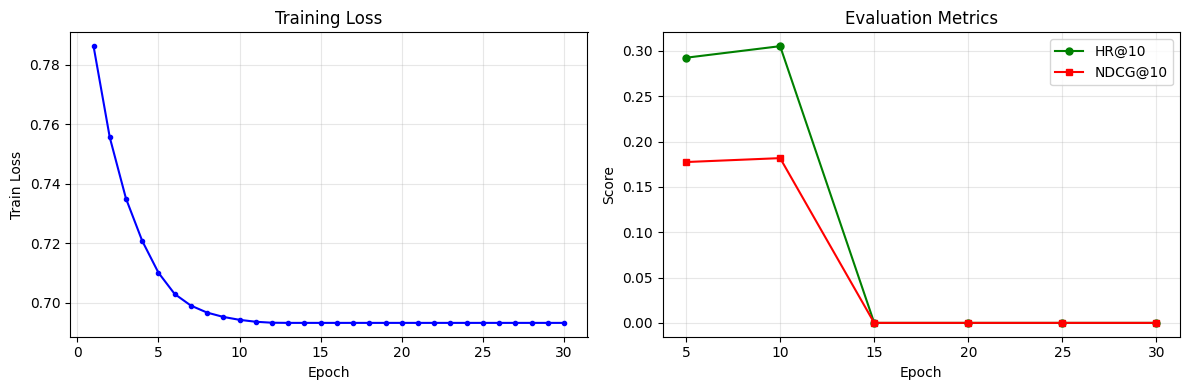


Final Baseline: HR@10=0.0000, NDCG@10=0.0000


In [10]:
# Plot training curves
import matplotlib.pyplot as plt

epochs_list = [h[0] for h in history]
losses = [h[1] for h in history]
eval_epochs = [h[0] for h in history if h[2]]
hr_values = [h[2]["HR@K"] for h in history if h[2]]
ndcg_values = [h[2]["NDCG@K"] for h in history if h[2]]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs_list, losses, "b-o", markersize=3)
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Train Loss")
ax1.set_title("Training Loss")
ax1.grid(True, alpha=0.3)

ax2.plot(eval_epochs, hr_values, "g-o", label="HR@10", markersize=5)
ax2.plot(eval_epochs, ndcg_values, "r-s", label="NDCG@10", markersize=5)
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Score")
ax2.set_title("Evaluation Metrics")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("results/baseline_training.png", dpi=150, bbox_inches="tight")
plt.show()

final = history[-1][2]
print(f"\nFinal Baseline: HR@10={final['HR@K']:.4f}, NDCG@10={final['NDCG@K']:.4f}")

## Phase 4: DLAttack — Targeted Data Poisoning

We select a mid-popularity target item and run 5 rounds of DLAttack, injecting 5 fake users per round (25 total).

In [11]:
# === ATTACK CONFIGURATION ===
ATTACK_ROUNDS = 5
FAKE_USERS_PER_ROUND = 5     # m = 5 -> 25 total fake users
N_FILLER = 30                 # filler items per fake user
N_OPTIM_STEPS = 200           # gradient steps per fake user
RETRAIN_EPOCHS = 10           # epochs when retraining on poisoned data

In [12]:
# Select target item (mid-popularity: 20-100 interactions)
item_counts = train_df["item_id"].value_counts()
mid_items = item_counts[(item_counts > 20) & (item_counts < 100)].index.tolist()
target_item = int(mid_items[0])

print(f"Target item ID: {target_item}")
print(f"Training interactions: {item_counts[target_item]}")
print(f"Mid-popularity candidates: {len(mid_items)} items")

Target item ID: 2035
Training interactions: 99
Mid-popularity candidates: 995 items


In [13]:
import json
from src.attack import run_dlattack
from src.distributed import deshard_state_dict

# Build on real device so we can load baseline weights before DMP wrapping
attack_ebc = build_ebc(n_users, n_items, EMBEDDING_DIM, device=DEVICE)
attack_tt = TwoTower(attack_ebc, layer_sizes=[128, 64], device=DEVICE)
attack_task = TwoTowerTrainTask(attack_tt)

# Load baseline checkpoint into plain model
baseline_state = deshard_state_dict(
    torch.load("checkpoints/baseline.pt", map_location=DEVICE, weights_only=False)
)
attack_task.load_state_dict(baseline_state, strict=False)

# Now wrap with DMP (preserves loaded weights)
attack_dmp, attack_dense_opt = wrap_with_dmp(attack_task, DEVICE, lr=LR)

eval_fn = lambda m: evaluate(m, test_df, train_df, n_items, n_neg=99, k=10, device=str(DEVICE))

attack_results, poisoned_train, attack_dmp, attack_dense_opt = run_dlattack(
    dmp_model=attack_dmp,
    dense_optimizer=attack_dense_opt,
    train_df=train_df,
    test_df=test_df,
    n_users=n_users,
    n_items=n_items,
    target_item_id=target_item,
    embedding_dim=EMBEDDING_DIM,
    layer_sizes=[128, 64],
    rounds=ATTACK_ROUNDS,
    m=FAKE_USERS_PER_ROUND,
    n_filler=N_FILLER,
    n_optim_steps=N_OPTIM_STEPS,
    retrain_epochs=RETRAIN_EPOCHS,
    lr=LR,
    device=str(DEVICE),
    eval_fn=eval_fn,
)

# Save
torch.save(extract_state_dict(attack_dmp), "checkpoints/attacked_model.pt")
poisoned_train.to_csv("results/poisoned_train.csv", index=False)
with open("results/attack_results.json", "w") as f:
    json.dump({"target_item": target_item, "rounds": attack_results}, f, indent=2)

print("\nAttack complete. Checkpoints saved.")


  [Before Attack] HR@10=0.0000 | NDCG@10=0.0000

  ATTACK ROUND 1/5  |  target_item=2035
  Retraining surrogate on 994169 interactions...
  Epoch   1 | loss=0.6931
  Epoch   2 | loss=0.6931
  Epoch   3 | loss=0.6931
  Epoch   4 | loss=0.6931
  Epoch   5 | loss=0.6931
  Epoch   6 | loss=0.6931
  Epoch   7 | loss=0.6931
  Epoch   8 | loss=0.6931
  Epoch   9 | loss=0.6931
  Epoch  10 | loss=0.6931
  Generating 5 fake users...


  Optimizing fake users: 100%|██████████| 5/5 [00:01<00:00,  3.50it/s]
/usr/local/lib/python3.12/dist-packages/torchrec/distributed/types.py:873: UserWarning: `_get_pg_default_device` will be deprecated, it only stays for backward-compatiblity reason. If you need to find a device for object collectives, please use `_get_object_coll_device`. If you need to query the device types supported by group, please use `_device_capability(group)`. 
  device_type=_get_pg_default_device(pg).type,


  Generated 5 fake users with 155 total interactions (avg 31.0/user)
  Poisoned training set: 994324 interactions (155 from fake users)
  Retraining main model on poisoned data...
  Epoch   1 | loss=0.6931
  Epoch   2 | loss=0.6931
  Epoch   3 | loss=0.6931
  Epoch   4 | loss=0.6931
  Epoch   5 | loss=0.6931
  Epoch   6 | loss=0.6931
  Epoch   7 | loss=0.6931
  Epoch   8 | loss=0.6931
  Epoch   9 | loss=0.6931
  Epoch  10 | loss=0.6931


  [After Round 1] HR@10=0.0000 | NDCG@10=0.0000

  ATTACK ROUND 2/5  |  target_item=2035
  Retraining surrogate on 994324 interactions...
  Epoch   1 | loss=0.6931
  Epoch   2 | loss=0.6931
  Epoch   3 | loss=0.6931
  Epoch   4 | loss=0.6931
  Epoch   5 | loss=0.6931
  Epoch   6 | loss=0.6931
  Epoch   7 | loss=0.6931
  Epoch   8 | loss=0.6931
  Epoch   9 | loss=0.6931
  Epoch  10 | loss=0.6931
  Generating 5 fake users...


  Optimizing fake users: 100%|██████████| 5/5 [00:01<00:00,  3.67it/s]
/usr/local/lib/python3.12/dist-packages/torchrec/distributed/types.py:873: UserWarning: `_get_pg_default_device` will be deprecated, it only stays for backward-compatiblity reason. If you need to find a device for object collectives, please use `_get_object_coll_device`. If you need to query the device types supported by group, please use `_device_capability(group)`. 
  device_type=_get_pg_default_device(pg).type,


...

  Optimizing fake users: 100%|██████████| 5/5 [00:01<00:00,  3.64it/s]
/usr/local/lib/python3.12/dist-packages/torchrec/distributed/types.py:873: UserWarning: `_get_pg_default_device` will be deprecated, it only stays for backward-compatiblity reason. If you need to find a device for object collectives, please use `_get_object_coll_device`. If you need to query the device types supported by group, please use `_device_capability(group)`. 
  device_type=_get_pg_default_device(pg).type,


  Generated 5 fake users with 155 total interactions (avg 31.0/user)
  Poisoned training set: 994789 interactions (620 from fake users)
  Retraining main model on poisoned data...
  Epoch   1 | loss=0.6931
  Epoch   2 | loss=0.6931
  Epoch   3 | loss=0.6931
  Epoch   4 | loss=0.6931
  Epoch   5 | loss=0.6931
  Epoch   6 | loss=0.6931
  Epoch   7 | loss=0.6931
  Epoch   8 | loss=0.6931
  Epoch   9 | loss=0.6931
  Epoch  10 | loss=0.6931


  [After Round 4] HR@10=0.0000 | NDCG@10=0.0000

  ATTACK ROUND 5/5  |  target_item=2035
  Retraining surrogate on 994789 interactions...
  Epoch   1 | loss=0.6931
  Epoch   2 | loss=0.6931
  Epoch   3 | loss=0.6931
  Epoch   4 | loss=0.6931
  Epoch   5 | loss=0.6931
  Epoch   6 | loss=0.6931
  Epoch   7 | loss=0.6931
  Epoch   8 | loss=0.6931
  Epoch   9 | loss=0.6931
  Epoch  10 | loss=0.6931
  Generating 5 fake users...


  Optimizing fake users: 100%|██████████| 5/5 [00:01<00:00,  3.50it/s]
/usr/local/lib/python3.12/dist-packages/torchrec/distributed/types.py:873: UserWarning: `_get_pg_default_device` will be deprecated, it only stays for backward-compatiblity reason. If you need to find a device for object collectives, please use `_get_object_coll_device`. If you need to query the device types supported by group, please use `_device_capability(group)`. 
  device_type=_get_pg_default_device(pg).type,


  Generated 5 fake users with 155 total interactions (avg 31.0/user)
  Poisoned training set: 994944 interactions (775 from fake users)
  Retraining main model on poisoned data...
  Epoch   1 | loss=0.6931
  Epoch   2 | loss=0.6931
  Epoch   3 | loss=0.6931
  Epoch   4 | loss=0.6931
  Epoch   5 | loss=0.6931
  Epoch   6 | loss=0.6931
  Epoch   7 | loss=0.6931
  Epoch   8 | loss=0.6931
  Epoch   9 | loss=0.6931
  Epoch  10 | loss=0.6931
  [After Round 5] HR@10=0.0000 | NDCG@10=0.0000

Attack complete. Checkpoints saved.


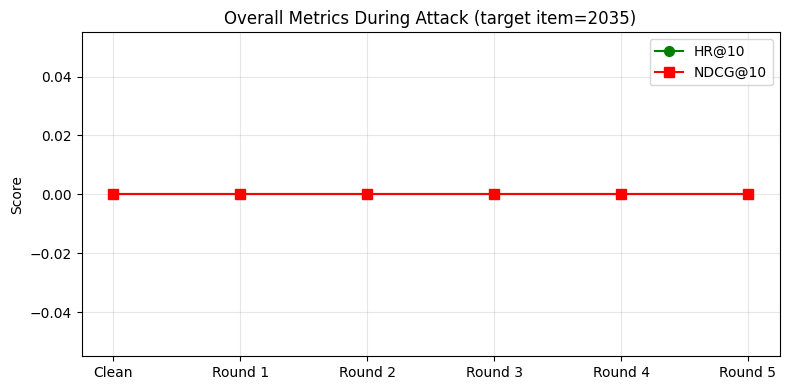

In [14]:
# Plot attack progress
rounds_keys = sorted([k for k in attack_results if k.startswith("round_")],
                     key=lambda x: int(x.split("_")[1]) if x.split("_")[1] != "0" else -1)

# Handle the clean round separately
round_labels = []
hr_vals = []
ndcg_vals = []
for k in rounds_keys:
    m = attack_results[k]
    label = "Clean" if "clean" in k else f"Round {k.split('_')[1]}"
    round_labels.append(label)
    hr_vals.append(m["HR@K"])
    ndcg_vals.append(m["NDCG@K"])

fig, ax = plt.subplots(figsize=(8, 4))
x = range(len(round_labels))
ax.plot(x, hr_vals, "g-o", label="HR@10", markersize=7)
ax.plot(x, ndcg_vals, "r-s", label="NDCG@10", markersize=7)
ax.set_xticks(list(x))
ax.set_xticklabels(round_labels)
ax.set_ylabel("Score")
ax.set_title(f"Overall Metrics During Attack (target item={target_item})")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("results/attack_progress.png", dpi=150, bbox_inches="tight")
plt.show()

## Phase 5: Attack Success Evaluation

The key metric is **target item HR@K** — how often the target item appears in top-K recommendations after the attack.

In [15]:
from src.evaluate import target_item_hit_ratio
from src.distributed import deshard_state_dict

def _load_two_tower(ckpt_path):
    """Load a plain TwoTower from a TwoTowerTrainTask checkpoint.
    Infers user/item counts from checkpoint shapes."""
    state = deshard_state_dict(
        torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
    )
    tt_state = {}
    for k, v in state.items():
        if k.startswith("two_tower."):
            tt_state[k[len("two_tower."):]] = v
    if tt_state:
        state = tt_state
    ckpt_n_users = state["ebc.embedding_bags.t_user_id.weight"].shape[0]
    ckpt_n_items = state["ebc.embedding_bags.t_item_id.weight"].shape[0]
    ebc = build_ebc(ckpt_n_users, ckpt_n_items, EMBEDDING_DIM, device=DEVICE)
    tt = TwoTower(ebc, layer_sizes=[128, 64], device=DEVICE)
    tt.load_state_dict(state, strict=False)
    return tt

clean_model = _load_two_tower("checkpoints/baseline.pt")
attacked_model = _load_two_tower("checkpoints/attacked_model.pt")

# Overall metrics
clean_overall = evaluate(clean_model, test_df, train_df, n_items, device=str(DEVICE))
attacked_overall = evaluate(attacked_model, test_df, train_df, n_items, device=str(DEVICE))

# Target item promotion
clean_thr = target_item_hit_ratio(clean_model, target_item, test_df, train_df, n_items, device=str(DEVICE))
attacked_thr = target_item_hit_ratio(attacked_model, target_item, test_df, train_df, n_items, device=str(DEVICE))

print("=" * 55)
print("             ATTACK EVALUATION RESULTS")
print("=" * 55)
print(f"  Target item ID:                {target_item}")
print(f"  Total fake users injected:     {ATTACK_ROUNDS * FAKE_USERS_PER_ROUND}")
print(f"  Filler items per fake user:    {N_FILLER}")
print("-" * 55)
print(f"  {'Metric':<30} {'Clean':>10} {'Attacked':>10}")
print("-" * 55)
print(f"  {'Overall HR@10':<30} {clean_overall['HR@K']:>10.4f} {attacked_overall['HR@K']:>10.4f}")
print(f"  {'Overall NDCG@10':<30} {clean_overall['NDCG@K']:>10.4f} {attacked_overall['NDCG@K']:>10.4f}")
print(f"  {'Target Item HR@10':<30} {clean_thr:>10.4f} {attacked_thr:>10.4f}")
print("-" * 55)
if clean_thr > 0:
    print(f"  Target item promotion factor:  {attacked_thr / clean_thr:.1f}x")
else:
    print(f"  Target item promotion:         {clean_thr:.4f} -> {attacked_thr:.4f}")
print("=" * 55)

             ATTACK EVALUATION RESULTS
  Target item ID:                2035
  Total fake users injected:     25
  Filler items per fake user:    30
-------------------------------------------------------
  Metric                              Clean   Attacked
-------------------------------------------------------
  Overall HR@10                      0.0000     0.0000
  Overall NDCG@10                    0.0000     0.0000
  Target Item HR@10                  0.0000     0.0000
-------------------------------------------------------
  Target item promotion:         0.0000 -> 0.0000


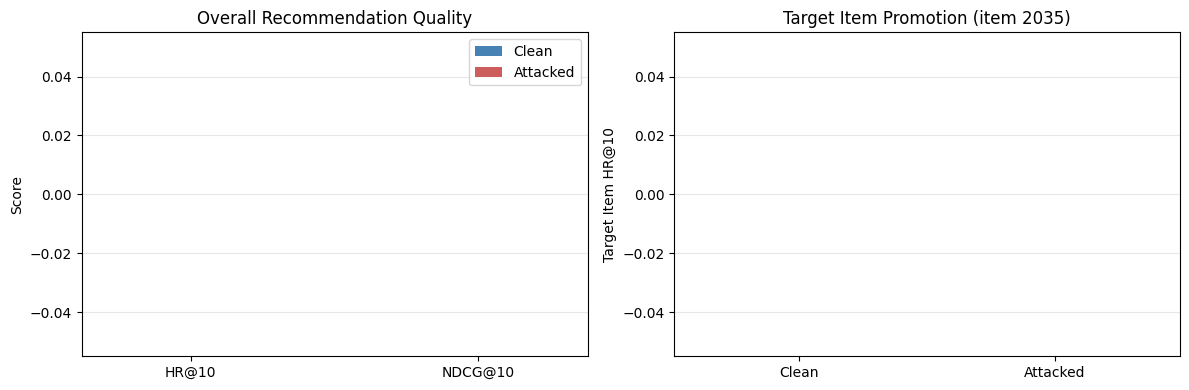

In [16]:
# Comparison bar chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Overall metrics
metrics = ["HR@10", "NDCG@10"]
clean_vals = [clean_overall["HR@K"], clean_overall["NDCG@K"]]
attacked_vals = [attacked_overall["HR@K"], attacked_overall["NDCG@K"]]
x = np.arange(len(metrics))
w = 0.3
ax1.bar(x - w/2, clean_vals, w, label="Clean", color="steelblue")
ax1.bar(x + w/2, attacked_vals, w, label="Attacked", color="indianred")
ax1.set_xticks(x)
ax1.set_xticklabels(metrics)
ax1.set_ylabel("Score")
ax1.set_title("Overall Recommendation Quality")
ax1.legend()
ax1.grid(True, alpha=0.3, axis="y")

# Target item promotion
ax2.bar(["Clean", "Attacked"], [clean_thr, attacked_thr],
        color=["steelblue", "indianred"])
ax2.set_ylabel("Target Item HR@10")
ax2.set_title(f"Target Item Promotion (item {target_item})")
ax2.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("results/attack_evaluation.png", dpi=150, bbox_inches="tight")
plt.show()

## Phase 6: Detection Baseline (TIA Method)

The TIA (Target Item Analysis) method detects fake users by measuring what fraction of each user's interactions are with items similar to the target item in embedding space.

In [17]:
from src.detect import detect_fake_users, compute_user_anomaly_scores

poisoned = pd.read_csv("results/poisoned_train.csv")

# Compute anomaly scores using plain TwoTower (already loaded above)
scores = compute_user_anomaly_scores(poisoned, attacked_model, target_item, n_items)

# Separate real vs fake user scores
fake_user_ids = set(poisoned[poisoned["user_id"] >= n_users]["user_id"].unique())
real_scores = scores[~scores.index.isin(fake_user_ids)]
fake_scores = scores[scores.index.isin(fake_user_ids)]

print(f"Real user scores — mean: {real_scores.mean():.4f}, std: {real_scores.std():.4f}")
print(f"Fake user scores — mean: {fake_scores.mean():.4f}, std: {fake_scores.std():.4f}")

Real user scores — mean: 0.0114, std: 0.0125
Fake user scores — mean: 0.1097, std: 0.0527


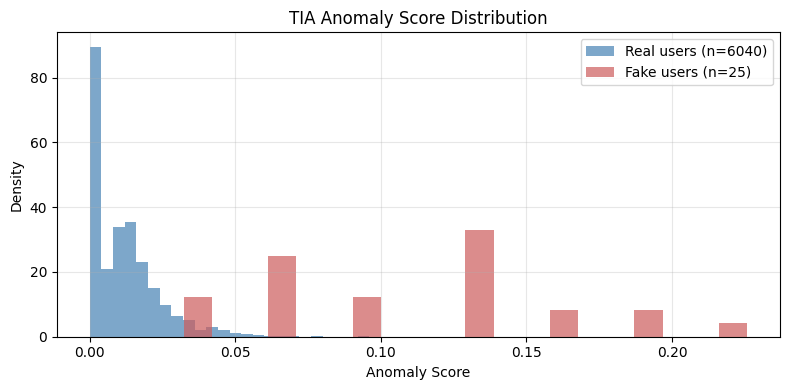

In [18]:
# Anomaly score distribution
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(real_scores, bins=50, alpha=0.7, label=f"Real users (n={len(real_scores)})",
        color="steelblue", density=True)
ax.hist(fake_scores, bins=20, alpha=0.7, label=f"Fake users (n={len(fake_scores)})",
        color="indianred", density=True)
ax.set_xlabel("Anomaly Score")
ax.set_ylabel("Density")
ax.set_title("TIA Anomaly Score Distribution")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("results/detection_scores.png", dpi=150, bbox_inches="tight")
plt.show()

In [19]:
# Detection at different thresholds
print(f"{'Percentile':<12} {'Threshold':<12} {'Precision':<12} {'Recall':<12} {'Flagged':<10}")
print("-" * 58)

for pct in [90, 92, 95, 97, 99]:
    threshold = np.percentile(scores.values, pct)
    flagged = set(scores[scores >= threshold].index.tolist())
    tp = len(flagged & fake_user_ids)
    precision = tp / max(len(flagged), 1)
    recall = tp / max(len(fake_user_ids), 1)
    print(f"  p{pct:<9} {threshold:<12.4f} {precision:<12.3f} {recall:<12.3f} {len(flagged):<10}")

Percentile   Threshold    Precision    Recall       Flagged   
----------------------------------------------------------
  p90        0.0270       0.041        1.000        613       
  p92        0.0294       0.050        1.000        501       
  p95        0.0352       0.072        0.880        305       
  p97        0.0421       0.121        0.880        182       
  p99        0.0556       0.344        0.880        64        


## Phase 7: Fake User Analysis

Inspect what the attack actually generated — which items did the fake users "interact" with?

In [20]:
fake_interactions = poisoned[poisoned["user_id"] >= n_users]
n_fake_users = fake_interactions["user_id"].nunique()
n_fake_interactions = len(fake_interactions)

print(f"Fake users: {n_fake_users}")
print(f"Total fake interactions: {n_fake_interactions}")
print(f"Avg interactions per fake user: {n_fake_interactions / n_fake_users:.1f}")
print(f"\nTarget item ({target_item}) appears in {(fake_interactions['item_id'] == target_item).sum()}/{n_fake_users} fake user profiles")

# Most common items in fake profiles
fake_item_counts = fake_interactions["item_id"].value_counts().head(15)
print(f"\nTop 15 items in fake user profiles:")
for item_id, count in fake_item_counts.items():
    real_pop = item_counts.get(item_id, 0)
    marker = " <-- TARGET" if item_id == target_item else ""
    print(f"  item {item_id:>5}: {count:>3} fake users, {real_pop:>4} real interactions{marker}")

Fake users: 25
Total fake interactions: 775
Avg interactions per fake user: 31.0

Target item (2035) appears in 25/25 fake user profiles

Top 15 items in fake user profiles:
  item  2035:  25 fake users,   99 real interactions <-- TARGET
  item   562:   8 fake users,  592 real interactions
  item  3600:   7 fake users,    2 real interactions
  item   280:   7 fake users, 1539 real interactions
  item   189:   7 fake users, 2526 real interactions
  item  2556:   6 fake users,  268 real interactions
  item   206:   6 fake users, 1594 real interactions
  item    68:   6 fake users, 1886 real interactions
  item   643:   6 fake users, 1438 real interactions
  item  2159:   6 fake users,  165 real interactions
  item  1622:   6 fake users,   24 real interactions
  item   537:   5 fake users, 1118 real interactions
  item    23:   5 fake users, 2289 real interactions
  item  2262:   5 fake users,  158 real interactions
  item    62:   5 fake users, 1985 real interactions


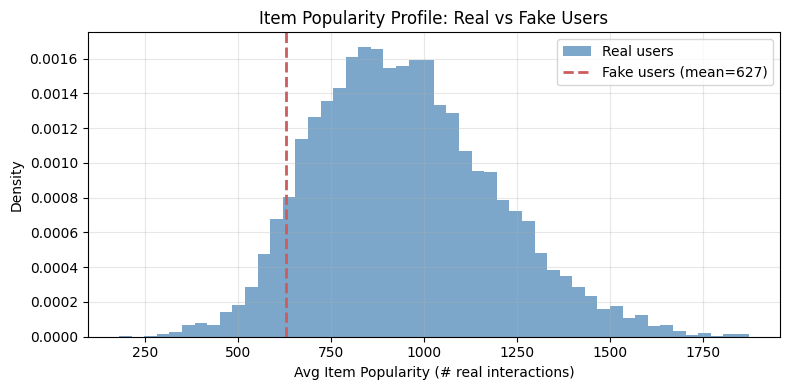

In [21]:
# Compare fake user item popularity distribution vs real users
real_interactions = poisoned[poisoned["user_id"] < n_users]

# Average popularity of items each user interacts with
real_avg_pop = real_interactions.groupby("user_id")["item_id"].apply(
    lambda items: item_counts.reindex(items).mean()
).dropna()
fake_avg_pop = fake_interactions.groupby("user_id")["item_id"].apply(
    lambda items: item_counts.reindex(items).mean()
).dropna()

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(real_avg_pop, bins=50, alpha=0.7, label="Real users", color="steelblue", density=True)
if len(fake_avg_pop) > 0:
    ax.axvline(fake_avg_pop.mean(), color="indianred", linewidth=2, linestyle="--",
               label=f"Fake users (mean={fake_avg_pop.mean():.0f})")
ax.set_xlabel("Avg Item Popularity (# real interactions)")
ax.set_ylabel("Density")
ax.set_title("Item Popularity Profile: Real vs Fake Users")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("results/fake_user_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

## Summary

Collect all results into a final summary table.

In [22]:
# Save all results
summary = {
    "dataset": "MovieLens-1M",
    "n_users": n_users,
    "n_items": n_items,
    "target_item": target_item,
    "target_item_real_interactions": int(item_counts[target_item]),
    "attack_config": {
        "rounds": ATTACK_ROUNDS,
        "fake_users_per_round": FAKE_USERS_PER_ROUND,
        "total_fake_users": ATTACK_ROUNDS * FAKE_USERS_PER_ROUND,
        "n_filler": N_FILLER,
        "n_optim_steps": N_OPTIM_STEPS,
    },
    "baseline": {
        "HR@10": clean_overall["HR@K"],
        "NDCG@10": clean_overall["NDCG@K"],
        "target_HR@10": clean_thr,
    },
    "attacked": {
        "HR@10": attacked_overall["HR@K"],
        "NDCG@10": attacked_overall["NDCG@K"],
        "target_HR@10": attacked_thr,
    },
}

with open("results/summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print(json.dumps(summary, indent=2))

{
  "dataset": "MovieLens-1M",
  "n_users": 6040,
  "n_items": 3706,
  "target_item": 2035,
  "target_item_real_interactions": 99,
  "attack_config": {
    "rounds": 5,
    "fake_users_per_round": 5,
    "total_fake_users": 25,
    "n_filler": 30,
    "n_optim_steps": 200
  },
  "baseline": {
    "HR@10": 0.0,
    "NDCG@10": 0.0,
    "target_HR@10": 0.0
  },
  "attacked": {
    "HR@10": 0.0,
    "NDCG@10": 0.0,
    "target_HR@10": 0.0
  }
}


In [23]:
# Download results (Colab)
try:
    from google.colab import files
    import shutil
    shutil.make_archive("dlattack_results", "zip", "results")
    files.download("dlattack_results.zip")
except ImportError:
    print("Not running on Colab — results saved in results/ directory")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>